In [47]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
import os
import sys
import warnings

if '../' not in sys.path:
    sys.path.append('../')

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

### directory with N_eff results

In [50]:
# adm_results_dir = '../output/results/scan/'
# adm_results_dir = '/Users/duncan/scrap/admscan/adm_scan/'
# adm_results_dir = '/Users/duncan/scrap/adm_test_scans/'
adm_results_dir = '/Users/duncan/scrap/adm_test_scans_fine_3/'

### Loop over directories to find all parameter points and load results

In [51]:
mde_dirs = []
mde_mdp_dirs = []

for name in os.listdir(adm_results_dir):
    if os.path.isdir(os.path.join(adm_results_dir, name)):
        mde_dirs.append(os.path.join(adm_results_dir, name))


for md in mde_dirs:
    for name in os.listdir(md):
        if os.path.isdir(os.path.join(md, name)):
            mde_mdp_dirs.append(os.path.join(md, name))
    
    

In [52]:
N_Q = 50
num_param_points = len(mde_mdp_dirs*N_Q)

m_de = np.zeros(num_param_points)
m_dp = np.zeros(num_param_points)
charges = np.zeros(num_param_points)
N_eff = np.zeros(num_param_points)
Delta_N_eff = np.zeros(num_param_points)
Delta_N_eff_dso = np.zeros(num_param_points)

res_ind = 0

for (i, res_dir) in enumerate(mde_mdp_dirs):
    result_files = [f for f in os.listdir(res_dir) if f.endswith('.npz')]
    
    for (j, rf) in enumerate(result_files):
        result = np.load(os.path.join(res_dir, rf))

        m_de[res_ind] = result['m_de']
        m_dp[res_ind] = result['m_dp']
        charges[res_ind] = result['Q']
        N_eff[res_ind] = result['N_eff_bsm']
        Delta_N_eff[res_ind] = result['Delta_Neff']
        Delta_N_eff_dso[res_ind] = result['DNeff_dso']

        res_ind += 1

failed_jobs = len(np.where(m_de == 0)[0])

In [53]:
sel = np.where(m_de > 0)

m_de = m_de[sel]
m_dp = m_dp[sel]
charges = charges[sel]
N_eff = N_eff[sel]
Delta_N_eff = Delta_N_eff[sel]
Delta_N_eff_dso = Delta_N_eff_dso[sel]

In [172]:
np.savez_compressed(
    os.path.join('../output/results/','neff_scan_result.npz'),
    m_de = m_de,
    m_dp = m_dp,
    eps = charges,
    N_eff = N_eff
)

### Plots

In [54]:
unique_mde = np.unique(m_de)

N_eff_results_dict = dict()
Delta_N_eff_interp_dict = dict()

for um_de in unique_mde:
    m_dp_um = m_dp[np.where(m_de == um_de)]

    unique_mdp = np.unique(m_dp_um)

    results_dict = dict()
    interp_dict = dict()

    for um_dp in unique_mdp:
        sel = np.where(
            (m_de == um_de)
           &(m_dp == um_dp)
        )


        
        charges_um_dp = charges[sel]
        N_eff_um_dp = N_eff[sel]
        Delta_N_eff_um_dp = Delta_N_eff[sel]
        Delta_N_eff_dso_um_dp = Delta_N_eff_dso[sel]

        sort_order = charges_um_dp.argsort()

        result_um_dp = np.array([
            charges_um_dp[sort_order], 
            N_eff_um_dp[sort_order],
            Delta_N_eff_um_dp[sort_order],
            Delta_N_eff_dso_um_dp[sort_order]
        ])

        dne_I = interp1d(
            charges_um_dp[sort_order], 
            Delta_N_eff_dso_um_dp[sort_order], 
            bounds_error=False, 
            fill_value=(Delta_N_eff_dso_um_dp[sort_order][0], Delta_N_eff_dso_um_dp[sort_order][-1])
        )

        results_dict = results_dict | {um_dp: result_um_dp}
        interp_dict = interp_dict | {um_dp: dne_I}

    N_eff_results_dict = N_eff_results_dict | {um_de: results_dict}
    Delta_N_eff_interp_dict = Delta_N_eff_interp_dict | {um_de: interp_dict}

In [37]:
list(N_eff_results_dict[0.1].keys())[-1]

100.0

In [38]:
print(unique_mde)

[  0.1      0.1151   0.1326   0.1526   0.1758   0.2024   0.233    0.2683
   0.3089   0.3556   0.4095   0.4715   0.5429   0.6251   0.7197   0.8286
   0.9541   1.099    1.265    1.456    1.677    1.931    2.223    2.56
   2.947    3.393    3.907    4.498    5.179    5.964    6.866    7.906
   9.103   10.48    12.07    13.89    16.      18.42    21.21    24.42
  28.12    32.37    37.28    42.92    49.42    56.9     65.51    75.43
  86.85   100.    ]


## Make Neff contour plot in hydrogen limit

In [11]:
masses_HL = np.zeros((len(unique_mde), N_Q))
charges_HL = np.zeros((len(unique_mde), N_Q))
N_eff_HL = np.zeros((len(unique_mde), N_Q))

for (i, mass_de) in enumerate(unique_mde):

    HL_mdp_key = list(N_eff_results_dict[mass_de].keys())[-1]
    charges = N_eff_results_dict[mass_de][HL_mdp_key][0]
    N_eff = N_eff_results_dict[mass_de][HL_mdp_key][1]

    masses_HL[i, :] = mass_de
    charges_HL[i, :] = charges
    N_eff_HL[i, :] = N_eff

    
contour_levels = np.array([2.8, 3.0, 3.2, 3.5, 3.844, 4.0, 4.5, 5, 7, 12, 20])
# contour_levels = np.array([3.26, 3.5, 3.844, 4.5, 5, 7])
# contour_levels = np.array([3.0, 3.26, 3.5,])
# contour_levels = 5

In [195]:
np.where(N_eff_HL > 100)

(array([10]), array([46]))

In [196]:
N_eff_HL[10]

array([3.00916842e+00, 3.00977055e+00, 3.02161331e+00, 3.01897820e+00,
       3.02795737e+00, 3.04470592e+00, 3.05340943e+00, 3.12738825e+00,
       3.28054602e+00, 3.66136521e+00, 4.66911035e+00, 6.66884473e+00,
       9.15673366e+00, 1.04877493e+01, 1.03650131e+01, 9.78795776e+00,
       9.16322690e+00, 8.74416047e+00, 8.52220704e+00, 8.40668505e+00,
       8.33243171e+00, 8.21070719e+00, 8.09204217e+00, 7.99019605e+00,
       7.90037359e+00, 7.82653307e+00, 7.76897000e+00, 7.69935938e+00,
       7.67130899e+00, 7.62927535e+00, 7.57372338e+00, 7.54815795e+00,
       7.53511992e+00, 7.48021102e+00, 7.47280907e+00, 7.46089989e+00,
       7.45073667e+00, 7.44555877e+00, 7.44038864e+00, 7.44014682e+00,
       6.89424161e+00, 7.68845704e+00, 7.44325459e+00, 6.03988359e+00,
       1.08161098e+01, 8.66740713e+00, 5.53118834e+03, 5.36697913e-01,
       1.29725557e+01, 5.89518449e+00])

In [197]:
masses_HL[10,46]
charges_HL[10,46]

4.292e-05

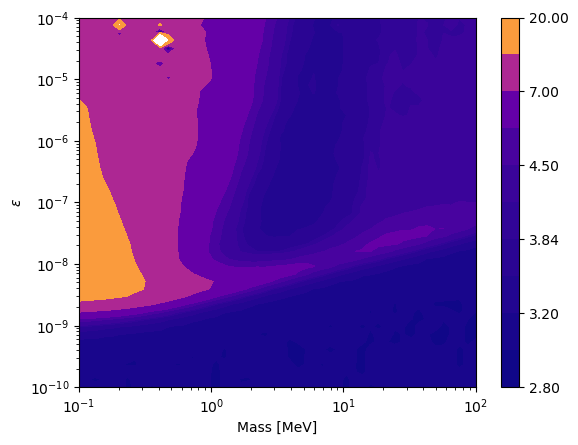

In [198]:
plt.contourf(
    masses_HL, 
    charges_HL, 
    N_eff_HL, 
    levels=contour_levels,
    cmap='plasma'
)
plt.colorbar()

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')
plt.xscale('log')
plt.yscale('log')

### Make some 1-d plots for specific mass points

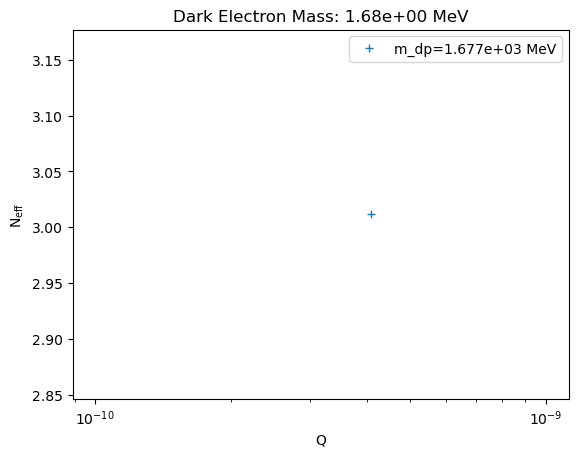

In [39]:
m_de_plot = unique_mde[20]

for m_dp in list(N_eff_results_dict[m_de_plot].keys()):
    charges_plot = N_eff_results_dict[m_de_plot][m_dp][0]
    N_eff_plot = N_eff_results_dict[m_de_plot][m_dp][1]
    
    plt.plot(charges_plot, N_eff_plot, linestyle='none', marker='+', label=f'{m_dp=:.3e} MeV')

plt.xscale('log')
plt.xlabel('Q')
plt.ylabel(r'N$_{\rm eff}$')
plt.legend()
plt.title(f'Dark Electron Mass: {m_de_plot:.2e} MeV')
plt.show()

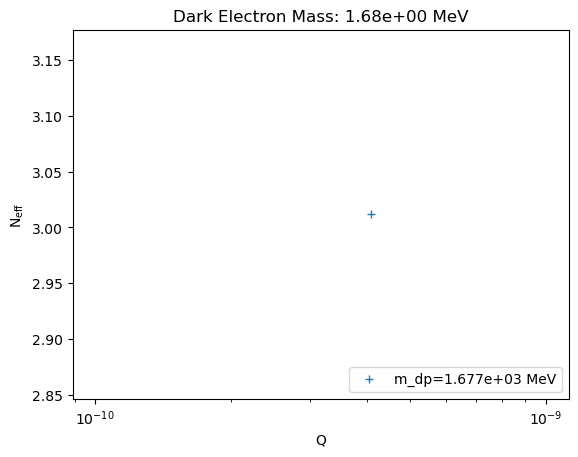

In [28]:
m_de_plot = unique_mde[20]

for m_dp in list(N_eff_results_dict[m_de_plot].keys())[::2]:
    charges_plot = N_eff_results_dict[m_de_plot][m_dp][0]
    N_eff_plot = N_eff_results_dict[m_de_plot][m_dp][1]
    
    plt.plot(charges_plot, N_eff_plot, linestyle='none', marker='+', label=f'{m_dp=:.3e} MeV')

plt.xscale('log')
plt.xlabel('Q')
plt.ylabel(r'N$_{\rm eff}$')
plt.legend(loc=4)
plt.title(f'Dark Electron Mass: {m_de_plot:.2e} MeV')
plt.show()

Text(0.5, 1.0, 'm_dp = 1000 m_de; eps = 4.095e-10')

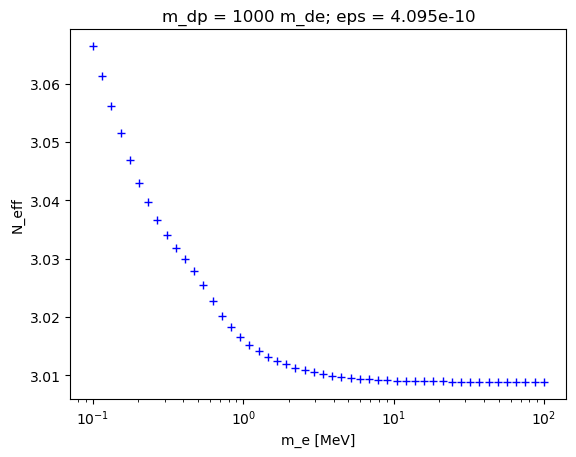

In [55]:
for m_de_plot in unique_mde:
    m_dp_plot_HL = list(N_eff_results_dict[m_de_plot].keys())[-1]
    charge = N_eff_results_dict[m_de_plot][m_dp_plot_HL][0]
    N_eff_BSM = N_eff_results_dict[m_de_plot][m_dp_plot_HL][1]
    plt.plot(m_de_plot, N_eff_BSM, marker='+', color='blue')
    plt.xscale('log')

plt.xlabel('m_e [MeV]')
plt.ylabel('N_eff')
plt.title('m_dp = 1000 m_de; eps = 4.095e-10')

In [16]:
N_eff_results_dict[0.1][100]

array([[4.09500000e-10],
       [3.06161961e+00],
       [3.57848771e-02],
       [3.61749194e-02]])